# Dangle Compare 2726

这个 notebook 用来对比 Slurm job `2726` 的两个 dangle 实验结果：

1. `dangle3_2726`：限制 `dangle_max_deg = 3`
2. `dangle_unlimited_2726`：不限制 dangle（`dangle_max_deg = 999`）

结果文件自动读取自：

- `runs/*/config.json`
- `runs/*/fig/metrics.json`
- `runs/*/fig/preds.npz`

并用 `preds.npz` 中的 `logE_true`、`logE_pred`、`mc_weight` 重新计算并绘制加权对比曲线：

- `resolution_weighted`
- `logRMS_weighted`
- `bias_weighted`


## 1. 设置路径并导入当前项目代码

这一格只做环境准备：定位项目根目录、输出目录，并导入当前整理后的 `src/common` 工具函数。

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/home/server/projects/energy_reconstruction')
NOTEBOOK_DIR = PROJECT_ROOT / 'notebook'
OUTPUT_DIR = NOTEBOOK_DIR / 'generated' / 'dangle_compare_2726'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common.utils import _weighted_mean, _weighted_std, _weighted_rms

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUTPUT_DIR   =', OUTPUT_DIR)


PROJECT_ROOT = /home/server/projects/energy_reconstruction
OUTPUT_DIR   = /home/server/projects/energy_reconstruction/notebook/generated/dangle_compare_2726


## 2. 定义实验目录并检查结果文件

这里把 job `2726` 的两个 run 明确绑定起来，并确认 notebook 后续要读取的文件都存在。

In [2]:
RUNS = {
    'dangle3': {
        'run_name': 'dangle3_2726',
        'display': 'dangle < 3°',
    },
    'dangle_unlimited': {
        'run_name': 'dangle_unlimited_2726',
        'display': 'dangle unrestricted',
    },
}

RESULTS = {}
for key, item in RUNS.items():
    run_dir = PROJECT_ROOT / 'runs' / item['run_name']
    fig_dir = run_dir / 'fig'
    config_path = run_dir / 'config.json'
    metrics_path = fig_dir / 'metrics.json'
    preds_path = fig_dir / 'preds.npz'

    assert run_dir.exists(), f'Missing run dir: {run_dir}'
    assert config_path.exists(), f'Missing config: {config_path}'
    assert metrics_path.exists(), f'Missing metrics: {metrics_path}'
    assert preds_path.exists(), f'Missing preds: {preds_path}'

    RESULTS[key] = {
        'display': item['display'],
        'run_dir': run_dir,
        'config_path': config_path,
        'metrics_path': metrics_path,
        'preds_path': preds_path,
    }

for key, item in RESULTS.items():
    print(f"{key:18s} -> {item['run_dir']}")
    print(f"  preds   : {item['preds_path']}")
    print(f"  metrics : {item['metrics_path']}")
    print(f"  config  : {item['config_path']}")


dangle3            -> /home/server/projects/energy_reconstruction/runs/dangle3_2726
  preds   : /home/server/projects/energy_reconstruction/runs/dangle3_2726/fig/preds.npz
  metrics : /home/server/projects/energy_reconstruction/runs/dangle3_2726/fig/metrics.json
  config  : /home/server/projects/energy_reconstruction/runs/dangle3_2726/config.json
dangle_unlimited   -> /home/server/projects/energy_reconstruction/runs/dangle_unlimited_2726
  preds   : /home/server/projects/energy_reconstruction/runs/dangle_unlimited_2726/fig/preds.npz
  metrics : /home/server/projects/energy_reconstruction/runs/dangle_unlimited_2726/fig/metrics.json
  config  : /home/server/projects/energy_reconstruction/runs/dangle_unlimited_2726/config.json


## 3. 读取 `config.json`、`metrics.json` 和 `preds.npz`

这一步不手工抄数据，直接从结果文件自动读取，并汇总整体指标作为对照。

In [3]:
loaded = {}
summary_rows = []

for key, item in RESULTS.items():
    with open(item['config_path'], 'r') as f:
        config = json.load(f)
    with open(item['metrics_path'], 'r') as f:
        metrics = json.load(f)
    preds = np.load(item['preds_path'])

    loaded[key] = {
        'display': item['display'],
        'config': config,
        'metrics': metrics,
        'logE_true': preds['logE_true'].astype(np.float64),
        'logE_pred': preds['logE_pred'].astype(np.float64),
        'mc_weight': preds['mc_weight'].astype(np.float64),
    }

    summary_rows.append({
        'experiment': item['display'],
        'run_name': item['run_dir'].name,
        'n': metrics['n'],
        'w_log_sigma': metrics['w_log_sigma'],
        'w_log_rmse': metrics['w_log_rmse'],
        'w_log_bias': metrics['w_log_bias'],
    })

for row in summary_rows:
    print(row)


{'experiment': 'dangle < 3°', 'run_name': 'dangle3_2726', 'n': 423617, 'w_log_sigma': 0.2077658294901778, 'w_log_rmse': 0.21144791312358688, 'w_log_bias': 0.0392884218963152}
{'experiment': 'dangle unrestricted', 'run_name': 'dangle_unlimited_2726', 'n': 503431, 'w_log_sigma': 0.3080862143639089, 'w_log_rmse': 0.31457505025124827, 'w_log_bias': 0.06356373136558688}


## 4. 用共享 true-energy bins 重算两条加权曲线

这里使用和 `src/common/utils.py` 相同的 weighted 统计定义，并在共同的 true-energy bin 上计算两条曲线，便于同图比较。

In [4]:
def compute_weighted_curves(log_true, log_pred, weights, bin_edges):
    mask = (
        np.isfinite(log_true)
        & np.isfinite(log_pred)
        & np.isfinite(weights)
        & (weights > 0)
    )

    log_true = log_true[mask]
    log_pred = log_pred[mask]
    weights = weights[mask]

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bias = []
    resolution = []
    log_rms = []

    for i in range(len(bin_edges) - 1):
        m = (log_true >= bin_edges[i]) & (log_true < bin_edges[i + 1])
        if m.sum() > 10:
            residual = log_pred[m] - log_true[m]
            w = weights[m]
            bias.append(float(_weighted_mean(residual, w)))
            resolution.append(float(_weighted_std(log_pred[m], w)))
            log_rms.append(float(_weighted_rms(residual, w)))
        else:
            bias.append(np.nan)
            resolution.append(np.nan)
            log_rms.append(np.nan)

    return {
        'bin_centers': centers,
        'bias': np.asarray(bias, dtype=np.float64),
        'resolution': np.asarray(resolution, dtype=np.float64),
        'log_rms': np.asarray(log_rms, dtype=np.float64),
    }

all_true = []
for item in loaded.values():
    mask = np.isfinite(item['logE_true'])
    all_true.append(item['logE_true'][mask])

combined_true = np.concatenate(all_true)
bin_edges = np.linspace(combined_true.min(), combined_true.max(), 21)

curves = {}
for key, item in loaded.items():
    curves[key] = compute_weighted_curves(
        item['logE_true'],
        item['logE_pred'],
        item['mc_weight'],
        bin_edges,
    )
    valid_bins = np.isfinite(curves[key]['bias']).sum()
    print(f"{item['display']}: valid bins = {valid_bins}")


dangle < 3°: valid bins = 20


dangle unrestricted: valid bins = 20


## 5. 定义统一绘图函数

三张图共用同一套颜色、标记和图例风格，方便直接比较。

In [5]:
plot_order = ['dangle3', 'dangle_unlimited']
colors = {
    'dangle3': '#1f77b4',
    'dangle_unlimited': '#9467bd',
}
markers = {
    'dangle3': 'o',
    'dangle_unlimited': 's',
}

def plot_compare(metric_key, ylabel, title, filename, draw_zero=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    for key in plot_order:
        item = loaded[key]
        curve = curves[key]
        ax.plot(
            curve['bin_centers'],
            curve[metric_key],
            marker=markers[key],
            color=colors[key],
            linewidth=2,
            markersize=5,
            label=item['display'],
        )

    if draw_zero:
        ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)

    ax.set_xlabel(r'True Energy $\log_{10}(E/\mathrm{GeV})$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=True)
    ax.grid(alpha=0.3)
    fig.tight_layout()

    out_path = OUTPUT_DIR / filename
    fig.savefig(out_path, dpi=200)
    plt.show()
    print('saved:', out_path)

    return out_path


## 6. 画 `resolution_weighted` 对比图

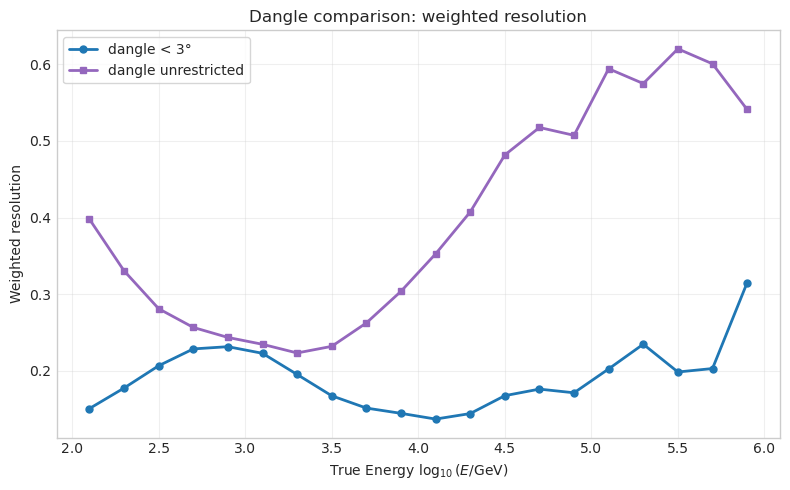

saved: /home/server/projects/energy_reconstruction/notebook/generated/dangle_compare_2726/resolution_weighted_compare_2726.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/dangle_compare_2726/resolution_weighted_compare_2726.png')

In [6]:
resolution_path = plot_compare(
    metric_key='resolution',
    ylabel='Weighted resolution',
    title='Dangle comparison: weighted resolution',
    filename='resolution_weighted_compare_2726.png',
)
resolution_path


## 7. 画 `logRMS_weighted` 对比图

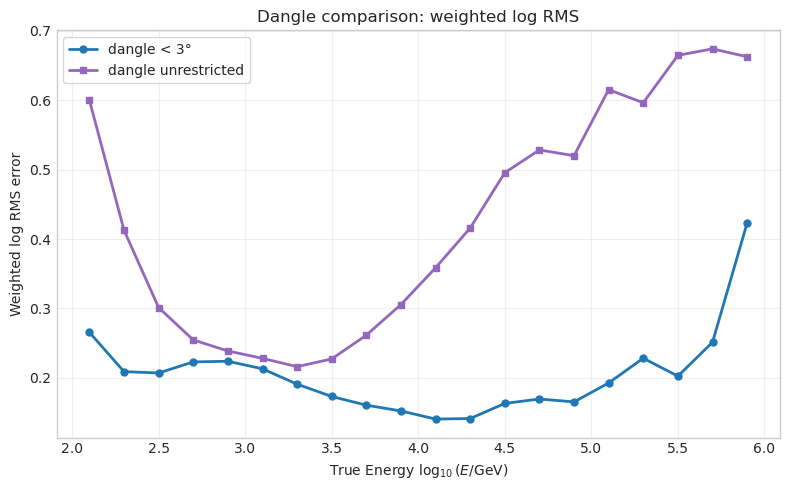

saved: /home/server/projects/energy_reconstruction/notebook/generated/dangle_compare_2726/logRMS_weighted_compare_2726.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/dangle_compare_2726/logRMS_weighted_compare_2726.png')

In [7]:
logrms_path = plot_compare(
    metric_key='log_rms',
    ylabel='Weighted log RMS error',
    title='Dangle comparison: weighted log RMS',
    filename='logRMS_weighted_compare_2726.png',
)
logrms_path


## 8. 画 `bias_weighted` 对比图

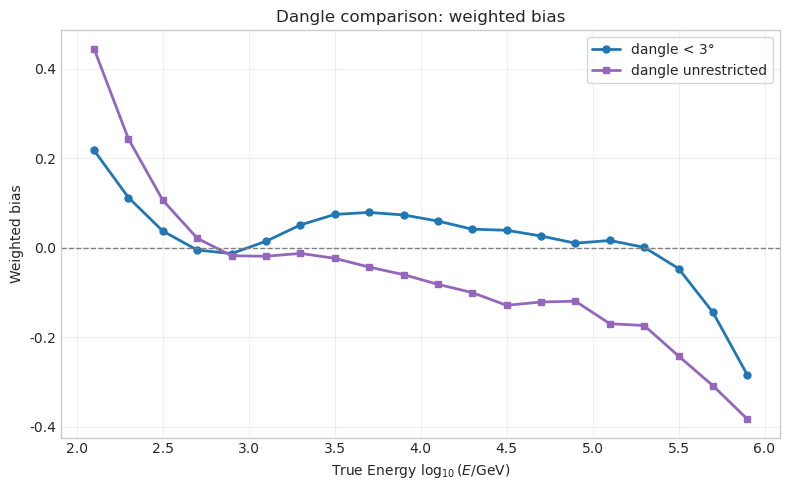

saved: /home/server/projects/energy_reconstruction/notebook/generated/dangle_compare_2726/bias_weighted_compare_2726.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/dangle_compare_2726/bias_weighted_compare_2726.png')

In [8]:
bias_path = plot_compare(
    metric_key='bias',
    ylabel='Weighted bias',
    title='Dangle comparison: weighted bias',
    filename='bias_weighted_compare_2726.png',
    draw_zero=True,
)
bias_path
